# 04 — Avaliação & Backtest (Validação)

Notebook auxiliar para análise detalhada dos resultados das Etapas A e B.
Gera a tabela comparativa consolidada e análises complementares.

In [1]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

from src.utils.mlflow_utils import get_all_runs_comparison

d:\5. Academia\4. Machine Learning Engineering - FIAP\projeto_4\lstm_financial\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Buscar todas as runs do MLflow
runs = get_all_runs_comparison()
if not runs.empty:
    cols_of_interest = [c for c in runs.columns if c.startswith('metrics.') or c.startswith('params.') or c == 'tags.mlflow.runName']
    display(runs[cols_of_interest].head(20))
else:
    print("Nenhuma run encontrada. Execute o notebook 03 primeiro.")

,metrics.val_loss,metrics.auc_roc,metrics.val_accuracy,metrics.bt_n_trades,metrics.bt_win_rate_pct,metrics.cls_log_loss,metrics.bt_retorno_acumulado_pct,metrics.bt_sharpe_ratio,metrics.cls_recall,metrics.bt_max_drawdown_pct,...,params.n_trials,params.best_lstm1_units,params.best_use_batchnorm,params.best_dropout_dense,params.best_l2_reg,params.best_batch_size,params.best_dense_units,params.best_dropout_lstm,params.tag_variant,tags.mlflow.runName
0,0.683803,0.556489,0.575000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,None,None,trial_024
1,0.709618,0.546550,0.555357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,None,None,trial_024
2,0.691113,0.542352,0.507143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,None,None,trial_040
3,0.686056,0.539229,0.578571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,None,None,trial_038
4,0.718532,0.536119,0.537500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,None,None,trial_026
5,0.705689,0.533061,0.530357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,None,None,trial_020
6,0.684736,0.532789,0.571429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,None,None,trial_047
7,0.685507,0.528967,0.562500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,None,None,trial_012
8,0.697843,0.528435,0.562500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,None,None,trial_031
9,0.719059,0.528409,0.551786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,None,None,trial_000


In [3]:
# Carregar tabela comparativa salva no notebook 03
try:
    df_comp = pd.read_csv('../reports/tabela_comparativa_AB.csv')
    display(df_comp)
except FileNotFoundError:
    print("Tabela comparativa não encontrada. Execute o notebook 03 primeiro.")

,Modelo,AUC-ROC,F1,Accuracy,Sharpe,Sortino,MaxDD%,WinRate%,RetAcum%
0,A - Baseline,0.536301,0.419958,0.501786,0.2307,0.1617,-27.15,58.43,41.02
1,B1_attention,0.513068,0.300716,0.476786,0.9132,0.6975,-9.89,60.58,78.34
2,B2_conv1d_lstm,0.486764,0.647137,0.526786,1.1148,1.4505,-22.69,54.82,159.51
3,B3_bidirectional,0.548377,0.577849,0.530357,1.4363,1.6548,-19.01,56.49,197.16
4,B4_lstm_gru,0.508202,0.695018,0.551786,1.1666,1.5894,-26.53,55.51,192.45


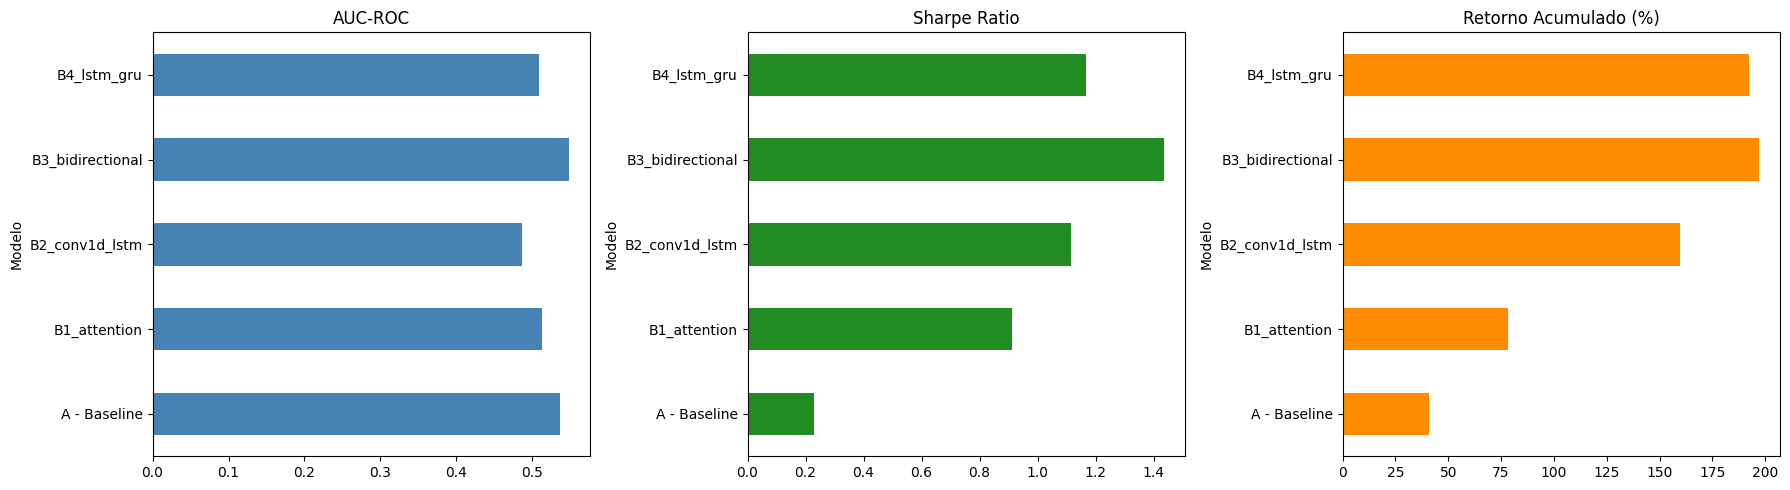

In [4]:
# Comparação visual
if 'df_comp' in dir() and not df_comp.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    df_comp.set_index('Modelo')['AUC-ROC'].plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title('AUC-ROC')
    
    df_comp.set_index('Modelo')['Sharpe'].plot(kind='barh', ax=axes[1], color='forestgreen')
    axes[1].set_title('Sharpe Ratio')
    
    df_comp.set_index('Modelo')['RetAcum%'].plot(kind='barh', ax=axes[2], color='darkorange')
    axes[2].set_title('Retorno Acumulado (%)')
    
    plt.tight_layout()
    plt.savefig('../reports/comparacao_modelos.png', dpi=150, bbox_inches='tight')
    plt.show()